In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [27]:
# Load the Excel dataset

df = pd.read_excel("Online Retail.xlsx")

# Display the first 5 rows
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [28]:
# Check dataset shape
print("Dataset Shape:", df.shape)

# Display column names
print("\nColumns:")
print(df.columns)

# Check data types and missing values
print("\nDataset Information:")
df.info()

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (541909, 8)

Columns:
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB

Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
I

In [29]:
# Create a cleaned copy of the dataset
df_clean = df.copy()

# Remove rows with missing CustomerID
df_clean = df_clean.dropna(subset=["CustomerID"])

# Remove rows with missing Description
df_clean = df_clean.dropna(subset=["Description"])

# Keep only valid transactions
df_clean = df_clean[
    (df_clean["Quantity"] > 0) &
    (df_clean["UnitPrice"] > 0)
]

# Convert CustomerID to integer
df_clean["CustomerID"] = df_clean["CustomerID"].astype(int)

# Check the cleaned dataset
print("Cleaned Dataset Shape:", df_clean.shape)

print("\nMissing Values:")
print(df_clean.isnull().sum())

# Display first 5 rows
df_clean.head()

Cleaned Dataset Shape: (397884, 8)

Missing Values:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


In [30]:
# Create Total Amount column

df_clean["TotalAmount"] = (
    df_clean["Quantity"] * df_clean["UnitPrice"]
)

# Display first 5 rows
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [31]:
# Step 8: Basic Exploratory Data Analysis (EDA)

# Dataset shape
print("Dataset Shape:", df_clean.shape)

# Basic statistical summary
print("\nStatistical Summary:")
display(df_clean.describe())

# Check data types
print("\nData Types:")
print(df_clean.dtypes)

# Display first 5 rows
print("\nFirst 5 Rows:")
display(df_clean.head())

Dataset Shape: (397884, 9)

Statistical Summary:


,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalAmount
count,397884.000000,397884,397884.000000,397884.000000,397884.000000
mean,12.988238,2011-07-10 23:41:23.511023360,3.116488,15294.423453,22.397000
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,13969.000000,4.680000
50%,6.000000,2011-07-31 14:39:00,1.950000,15159.000000,11.800000
75%,12.000000,2011-10-20 14:33:00,3.750000,16795.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,179.331775,NaN,22.097877,1713.141560,309.071041



Data Types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              int64
Country                object
TotalAmount           float64
dtype: object

First 5 Rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [32]:
# Step 9: Overall Revenue & Sales Analysis

# Total Revenue
total_revenue = df_clean["TotalAmount"].sum()

# Number of unique customers
total_customers = df_clean["CustomerID"].nunique()

# Number of unique invoices/orders
total_orders = df_clean["InvoiceNo"].nunique()

# Average Order Value
average_order_value = total_revenue / total_orders

# Average Revenue per Customer
average_revenue_per_customer = total_revenue / total_customers

# Display results
print("Total Revenue: £", round(total_revenue, 2))
print("Total Customers:", total_customers)
print("Total Orders:", total_orders)
print("Average Order Value: £", round(average_order_value, 2))
print("Average Revenue per Customer: £", round(average_revenue_per_customer, 2))

Total Revenue: £ 8911407.9
Total Customers: 4338
Total Orders: 18532
Average Order Value: £ 480.87
Average Revenue per Customer: £ 2054.27


In [33]:
# Step 10: Monthly Revenue Analysis

# Make sure InvoiceDate is in datetime format
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

# Extract year and month
df_clean["YearMonth"] = df_clean["InvoiceDate"].dt.to_period("M")

# Calculate monthly revenue
monthly_revenue = (
    df_clean.groupby("YearMonth")["TotalAmount"]
    .sum()
    .reset_index()
)

# Convert YearMonth to string for easier plotting
monthly_revenue["YearMonth"] = monthly_revenue["YearMonth"].astype(str)

# Display monthly revenue
display(monthly_revenue)

,YearMonth,TotalAmount
0,2010-12,572713.890
1,2011-01,569445.040
2,2011-02,447137.350
3,2011-03,595500.760
4,2011-04,469200.361
5,2011-05,678594.560
6,2011-06,661213.690
7,2011-07,600091.011
8,2011-08,645343.900
9,2011-09,952838.382


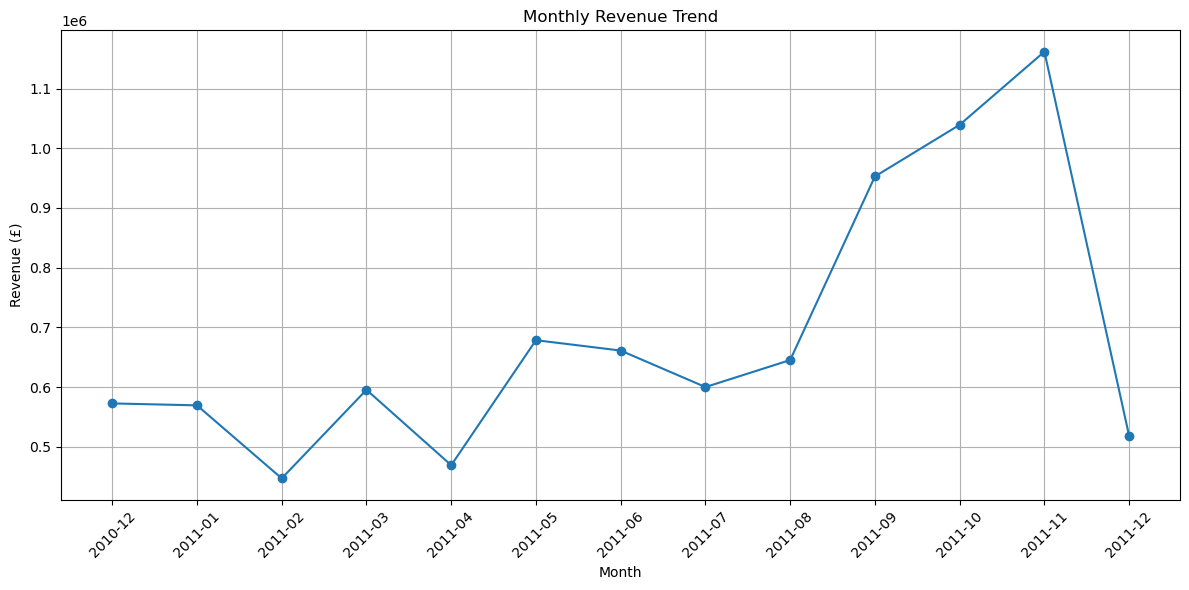

In [34]:
# Plot Monthly Revenue

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue["YearMonth"],
    monthly_revenue["TotalAmount"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

In [35]:
# Step 11: Customer Purchase & Revenue Analysis

# Calculate customer-level metrics
customer_analysis = (
    df_clean.groupby("CustomerID")
    .agg(
        TotalOrders=("InvoiceNo", "nunique"),
        TotalQuantity=("Quantity", "sum"),
        TotalRevenue=("TotalAmount", "sum")
    )
    .reset_index()
)

# Display first 10 customers
display(customer_analysis.head(10))

,CustomerID,TotalOrders,TotalQuantity,TotalRevenue
0,12346,1,74215,77183.60
1,12347,7,2458,4310.00
2,12348,4,2341,1797.24
3,12349,1,631,1757.55
4,12350,1,197,334.40
5,12352,8,536,2506.04
6,12353,1,20,89.00
7,12354,1,530,1079.40
8,12355,1,240,459.40
9,12356,3,1591,2811.43


In [36]:
# Summary statistics of customer behavior

print("Customer Analysis Summary:")

display(
    customer_analysis[
        ["TotalOrders", "TotalQuantity", "TotalRevenue"]
    ].describe()
)

Customer Analysis Summary:


,TotalOrders,TotalQuantity,TotalRevenue
count,4338.000000,4338.000000,4338.000000
mean,4.272015,1191.289073,2054.266460
std,7.697998,5046.081546,8989.230441
min,1.000000,1.000000,3.750000
25%,1.000000,160.000000,307.415000
50%,2.000000,379.000000,674.485000
75%,5.000000,992.750000,1661.740000
max,209.000000,196915.000000,280206.020000


In [37]:
# Top 10 customers by revenue

top_customers = (
    customer_analysis
    .sort_values("TotalRevenue", ascending=False)
    .head(10)
)

display(top_customers)

,CustomerID,TotalOrders,TotalQuantity,TotalRevenue
1689,14646,73,196915,280206.02
4201,18102,60,64124,259657.30
3728,17450,46,69993,194550.79
3008,16446,2,80997,168472.50
1879,14911,201,80265,143825.06
55,12415,21,77374,124914.53
1333,14156,55,57885,117379.63
3771,17511,31,64549,91062.38
2702,16029,63,40208,81024.84
0,12346,1,74215,77183.60


In [38]:
# Step 12: RFM Analysis

# Find the latest transaction date
latest_date = df_clean["InvoiceDate"].max()

print("Latest Transaction Date:", latest_date)

Latest Transaction Date: 2011-12-09 12:50:00


In [39]:
# Calculate RFM metrics

rfm = (
    df_clean.groupby("CustomerID")
    .agg(
        Recency=("InvoiceDate", lambda x: 
                 (latest_date - x.max()).days),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("TotalAmount", "sum")
    )
    .reset_index()
)

# Display first 10 customers
display(rfm.head(10))

,CustomerID,Recency,Frequency,Monetary
0,12346,325,1,77183.60
1,12347,1,7,4310.00
2,12348,74,4,1797.24
3,12349,18,1,1757.55
4,12350,309,1,334.40
5,12352,35,8,2506.04
6,12353,203,1,89.00
7,12354,231,1,1079.40
8,12355,213,1,459.40
9,12356,22,3,2811.43


In [40]:
# Step 13: RFM Scoring

# Create RFM scores from 1 to 5
# Rank(method="first") prevents duplicate-value errors in qcut

rfm["R_Score"] = pd.qcut(
    rfm["Recency"].rank(method="first"),
    5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

# Display the results
display(rfm.head(10))

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,12346,325,1,77183.60,1,1,5
1,12347,1,7,4310.00,5,5,5
2,12348,74,4,1797.24,2,4,4
3,12349,18,1,1757.55,4,1,4
4,12350,309,1,334.40,1,1,2
5,12352,35,8,2506.04,3,5,5
6,12353,203,1,89.00,1,1,1
7,12354,231,1,1079.40,1,1,4
8,12355,213,1,459.40,1,1,2
9,12356,22,3,2811.43,4,3,5


In [41]:
# Create combined RFM score

rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    + rfm["F_Score"].astype(str)
    + rfm["M_Score"].astype(str)
)

# Create total numerical score
rfm["RFM_Total"] = (
    rfm["R_Score"]
    + rfm["F_Score"]
    + rfm["M_Score"]
)

# Display top customers by RFM score
display(
    rfm.sort_values("RFM_Total", ascending=False)
       .head(10)
)

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total
1058,13777,0,33,25977.16,5,5,5,555,15
1044,13755,3,9,2161.35,5,5,5,555,15
1045,13756,1,14,5189.52,5,5,5,555,15
1046,13758,11,7,3190.55,5,5,5,555,15
1069,13798,0,57,37153.85,5,5,5,555,15
1063,13784,9,11,2462.79,5,5,5,555,15
1053,13767,1,37,17220.36,5,5,5,555,15
1054,13769,1,10,2796.51,5,5,5,555,15
918,13576,9,18,6717.34,5,5,5,555,15
914,13571,12,12,2092.32,5,5,5,555,15


In [42]:
# Step 14: Customer Segmentation

def customer_segment(row):

    R = row["R_Score"]
    F = row["F_Score"]
    M = row["M_Score"]

    # Champions
    if R >= 4 and F >= 4 and M >= 4:
        return "Champions"

    # Loyal Customers
    elif R >= 3 and F >= 3 and M >= 3:
        return "Loyal Customers"

    # Potential Loyalists
    elif R >= 4 and F >= 2:
        return "Potential Loyalists"

    # New Customers
    elif R == 5 and F == 1:
        return "New Customers"

    # Can't Lose Them
    elif R <= 2 and F >= 4 and M >= 4:
        return "Can't Lose Them"

    # At Risk
    elif R <= 3 and F >= 3:
        return "At Risk"

    # Lost Customers
    elif R <= 2 and F <= 2 and M <= 2:
        return "Lost Customers"

    # Hibernating
    else:
        return "Hibernating"


# Apply segmentation
rfm["Segment"] = rfm.apply(customer_segment, axis=1)

# Display sample
display(rfm.head(10))

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total,Segment
0,12346,325,1,77183.60,1,1,5,115,7,Hibernating
1,12347,1,7,4310.00,5,5,5,555,15,Champions
2,12348,74,4,1797.24,2,4,4,244,10,Can't Lose Them
3,12349,18,1,1757.55,4,1,4,414,9,Hibernating
4,12350,309,1,334.40,1,1,2,112,4,Lost Customers
5,12352,35,8,2506.04,3,5,5,355,13,Loyal Customers
6,12353,203,1,89.00,1,1,1,111,3,Lost Customers
7,12354,231,1,1079.40,1,1,4,114,6,Hibernating
8,12355,213,1,459.40,1,1,2,112,4,Lost Customers
9,12356,22,3,2811.43,4,3,5,435,12,Loyal Customers


In [43]:
# Customer count by segment

segment_counts = (
    rfm["Segment"]
    .value_counts()
    .reset_index()
)

segment_counts.columns = ["Segment", "CustomerCount"]

display(segment_counts)

,Segment,CustomerCount
0,Champions,947
1,Lost Customers,828
2,Loyal Customers,761
3,Hibernating,692
4,At Risk,574
5,Potential Loyalists,321
6,Can't Lose Them,173
7,New Customers,42


In [44]:
# Revenue by customer segment

segment_revenue = (
    rfm.groupby("Segment")["Monetary"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

segment_revenue.columns = ["Segment", "TotalRevenue"]

display(segment_revenue)

,Segment,TotalRevenue
0,Champions,5755513.220
1,Loyal Customers,1426733.721
2,Hibernating,528076.681
3,At Risk,463998.821
4,Can't Lose Them,390109.940
5,Lost Customers,190632.991
6,Potential Loyalists,140037.590
7,New Customers,16304.940


In [45]:
# Step 15: Customer Count by Segment

segment_counts = (
    rfm["Segment"]
    .value_counts()
    .reset_index()
)

segment_counts.columns = ["Segment", "CustomerCount"]

display(segment_counts)

,Segment,CustomerCount
0,Champions,947
1,Lost Customers,828
2,Loyal Customers,761
3,Hibernating,692
4,At Risk,574
5,Potential Loyalists,321
6,Can't Lose Them,173
7,New Customers,42


In [46]:
# Recreate RFM DataFrame

latest_date = df_clean["InvoiceDate"].max()

rfm = (
    df_clean.groupby("CustomerID")
    .agg(
        Recency=("InvoiceDate", lambda x:
                 (latest_date - x.max()).days),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("TotalAmount", "sum")
    )
    .reset_index()
)

display(rfm.head())

,CustomerID,Recency,Frequency,Monetary
0,12346,325,1,77183.60
1,12347,1,7,4310.00
2,12348,74,4,1797.24
3,12349,18,1,1757.55
4,12350,309,1,334.40


In [47]:
# Check current variables

print("df_clean exists:", "df_clean" in globals())
print("df exists:", "df" in globals())

df_clean exists: True
df exists: True


In [48]:
import os

# Show files available in the current working directory
print(os.listdir())

['.local', '.jupyter', '.pythonstartup.py', 'Project_2_Customer_Analytics.ipynb.', '.cache', '.ipython', 'creditcard.csv', '.vimrc', 'anaconda_projects', '.anaconda', '.conda', 'creditcard_cleaned.csv', '.npm', 'Credit-Card-Fraud-Detection.ipynb', '.virtualenvs', '.gitconfig', '.ipynb_checkpoints', 'Online Retail.xlsx', '.config', 'fraud_correlation.png', '.profile', '.bashrc']


In [49]:
# Check the Customer Segmentation notebook

import json

notebook_path = "Customer_Segmentation_CLV_Analysis.ipynb"

with open(notebook_path, "r", encoding="utf-8") as f:
    notebook = json.load(f)

# Display all code cells
for i, cell in enumerate(notebook["cells"]):
    if cell["cell_type"] == "code":
        print(f"\n{'='*60}")
        print(f"CELL {i}")
        print('='*60)
        print("".join(cell["source"]))

FileNotFoundError: [Errno 2] No such file or directory: 'Customer_Segmentation_CLV_Analysis.ipynb'

In [4]:
# Restore the dataset after kernel restart

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load original dataset
df = pd.read_excel("Online Retail.xlsx")

# Recreate cleaned dataset
df_clean = df.copy()

# Remove missing CustomerID and Description
df_clean = df_clean.dropna(subset=["CustomerID"])
df_clean = df_clean.dropna(subset=["Description"])

# Keep only valid transactions
df_clean = df_clean[
    (df_clean["Quantity"] > 0) &
    (df_clean["UnitPrice"] > 0)
]

# Convert CustomerID to integer
df_clean["CustomerID"] = df_clean["CustomerID"].astype(int)

# Create TotalAmount
df_clean["TotalAmount"] = (
    df_clean["Quantity"] * df_clean["UnitPrice"]
)

# Convert InvoiceDate
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

print("Dataset restored successfully!")
print("Original Dataset:", df.shape)
print("Cleaned Dataset:", df_clean.shape)

display(df_clean.head())

Dataset restored successfully!
Original Dataset: (541909, 8)
Cleaned Dataset: (397884, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [5]:
# Recreate RFM DataFrame

latest_date = df_clean["InvoiceDate"].max()

print("Latest Transaction Date:", latest_date)

rfm = (
    df_clean.groupby("CustomerID")
    .agg(
        Recency=("InvoiceDate", lambda x:
                 (latest_date - x.max()).days),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("TotalAmount", "sum")
    )
    .reset_index()
)

display(rfm.head(10))

Latest Transaction Date: 2011-12-09 12:50:00


,CustomerID,Recency,Frequency,Monetary
0,12346,325,1,77183.60
1,12347,1,7,4310.00
2,12348,74,4,1797.24
3,12349,18,1,1757.55
4,12350,309,1,334.40
5,12352,35,8,2506.04
6,12353,203,1,89.00
7,12354,231,1,1079.40
8,12355,213,1,459.40
9,12356,22,3,2811.43


In [6]:
# Recreate RFM scores

rfm["R_Score"] = pd.qcut(
    rfm["Recency"].rank(method="first"),
    5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    + rfm["F_Score"].astype(str)
    + rfm["M_Score"].astype(str)
)

rfm["RFM_Total"] = (
    rfm["R_Score"]
    + rfm["F_Score"]
    + rfm["M_Score"]
)

display(rfm.head(10))

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total
0,12346,325,1,77183.60,1,1,5,115,7
1,12347,1,7,4310.00,5,5,5,555,15
2,12348,74,4,1797.24,2,4,4,244,10
3,12349,18,1,1757.55,4,1,4,414,9
4,12350,309,1,334.40,1,1,2,112,4
5,12352,35,8,2506.04,3,5,5,355,13
6,12353,203,1,89.00,1,1,1,111,3
7,12354,231,1,1079.40,1,1,4,114,6
8,12355,213,1,459.40,1,1,2,112,4
9,12356,22,3,2811.43,4,3,5,435,12


In [7]:
# Recreate customer segments

def customer_segment(row):

    R = row["R_Score"]
    F = row["F_Score"]
    M = row["M_Score"]

    if R >= 4 and F >= 4 and M >= 4:
        return "Champions"

    elif R >= 3 and F >= 3 and M >= 3:
        return "Loyal Customers"

    elif R >= 4 and F >= 2:
        return "Potential Loyalists"

    elif R == 5 and F == 1:
        return "New Customers"

    elif R <= 2 and F >= 4 and M >= 4:
        return "Can't Lose Them"

    elif R <= 3 and F >= 3:
        return "At Risk"

    elif R <= 2 and F <= 2 and M <= 2:
        return "Lost Customers"

    else:
        return "Hibernating"


rfm["Segment"] = rfm.apply(customer_segment, axis=1)

display(rfm.head(10))

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total,Segment
0,12346,325,1,77183.60,1,1,5,115,7,Hibernating
1,12347,1,7,4310.00,5,5,5,555,15,Champions
2,12348,74,4,1797.24,2,4,4,244,10,Can't Lose Them
3,12349,18,1,1757.55,4,1,4,414,9,Hibernating
4,12350,309,1,334.40,1,1,2,112,4,Lost Customers
5,12352,35,8,2506.04,3,5,5,355,13,Loyal Customers
6,12353,203,1,89.00,1,1,1,111,3,Lost Customers
7,12354,231,1,1079.40,1,1,4,114,6,Hibernating
8,12355,213,1,459.40,1,1,2,112,4,Lost Customers
9,12356,22,3,2811.43,4,3,5,435,12,Loyal Customers


In [8]:
# Customer Count by Segment

segment_counts = (
    rfm["Segment"]
    .value_counts()
    .reset_index()
)

segment_counts.columns = ["Segment", "CustomerCount"]

display(segment_counts)

,Segment,CustomerCount
0,Champions,947
1,Lost Customers,828
2,Loyal Customers,761
3,Hibernating,692
4,At Risk,574
5,Potential Loyalists,321
6,Can't Lose Them,173
7,New Customers,42


In [9]:
# Step 16: Revenue per Customer by Segment

segment_analysis = segment_counts.merge(
    segment_revenue,
    on="Segment",
    how="left"
)

segment_analysis["RevenuePerCustomer"] = (
    segment_analysis["TotalRevenue"]
    / segment_analysis["CustomerCount"]
)

# Sort by revenue per customer
segment_analysis = (
    segment_analysis
    .sort_values("RevenuePerCustomer", ascending=False)
    .reset_index(drop=True)
)

display(segment_analysis)

NameError: name 'segment_revenue' is not defined

In [10]:
# Recreate revenue by customer segment

segment_revenue = (
    rfm.groupby("Segment")["Monetary"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

segment_revenue.columns = ["Segment", "TotalRevenue"]

display(segment_revenue)

,Segment,TotalRevenue
0,Champions,5755513.220
1,Loyal Customers,1426733.721
2,Hibernating,528076.681
3,At Risk,463998.821
4,Can't Lose Them,390109.940
5,Lost Customers,190632.991
6,Potential Loyalists,140037.590
7,New Customers,16304.940


In [11]:
# Calculate revenue per customer

segment_analysis = segment_counts.merge(
    segment_revenue,
    on="Segment",
    how="left"
)

segment_analysis["RevenuePerCustomer"] = (
    segment_analysis["TotalRevenue"]
    / segment_analysis["CustomerCount"]
)

# Sort by revenue per customer
segment_analysis = (
    segment_analysis
    .sort_values("RevenuePerCustomer", ascending=False)
    .reset_index(drop=True)
)

# Round values
segment_analysis["TotalRevenue"] = (
    segment_analysis["TotalRevenue"].round(2)
)

segment_analysis["RevenuePerCustomer"] = (
    segment_analysis["RevenuePerCustomer"].round(2)
)

display(segment_analysis)

,Segment,CustomerCount,TotalRevenue,RevenuePerCustomer
0,Champions,947,5755513.22,6077.63
1,Can't Lose Them,173,390109.94,2254.97
2,Loyal Customers,761,1426733.72,1874.81
3,At Risk,574,463998.82,808.36
4,Hibernating,692,528076.68,763.12
5,Potential Loyalists,321,140037.59,436.25
6,New Customers,42,16304.94,388.21
7,Lost Customers,828,190632.99,230.23


In [12]:
# Recreate revenue by customer segment

segment_revenue = (
    rfm.groupby("Segment")["Monetary"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

segment_revenue.columns = ["Segment", "TotalRevenue"]

display(segment_revenue)

,Segment,TotalRevenue
0,Champions,5755513.220
1,Loyal Customers,1426733.721
2,Hibernating,528076.681
3,At Risk,463998.821
4,Can't Lose Them,390109.940
5,Lost Customers,190632.991
6,Potential Loyalists,140037.590
7,New Customers,16304.940


In [13]:
# Calculate revenue per customer

segment_analysis = segment_counts.merge(
    segment_revenue,
    on="Segment",
    how="left"
)

segment_analysis["RevenuePerCustomer"] = (
    segment_analysis["TotalRevenue"]
    / segment_analysis["CustomerCount"]
)

# Sort by revenue per customer
segment_analysis = (
    segment_analysis
    .sort_values("RevenuePerCustomer", ascending=False)
    .reset_index(drop=True)
)

# Round values
segment_analysis["TotalRevenue"] = (
    segment_analysis["TotalRevenue"].round(2)
)

segment_analysis["RevenuePerCustomer"] = (
    segment_analysis["RevenuePerCustomer"].round(2)
)

display(segment_analysis)

,Segment,CustomerCount,TotalRevenue,RevenuePerCustomer
0,Champions,947,5755513.22,6077.63
1,Can't Lose Them,173,390109.94,2254.97
2,Loyal Customers,761,1426733.72,1874.81
3,At Risk,574,463998.82,808.36
4,Hibernating,692,528076.68,763.12
5,Potential Loyalists,321,140037.59,436.25
6,New Customers,42,16304.94,388.21
7,Lost Customers,828,190632.99,230.23


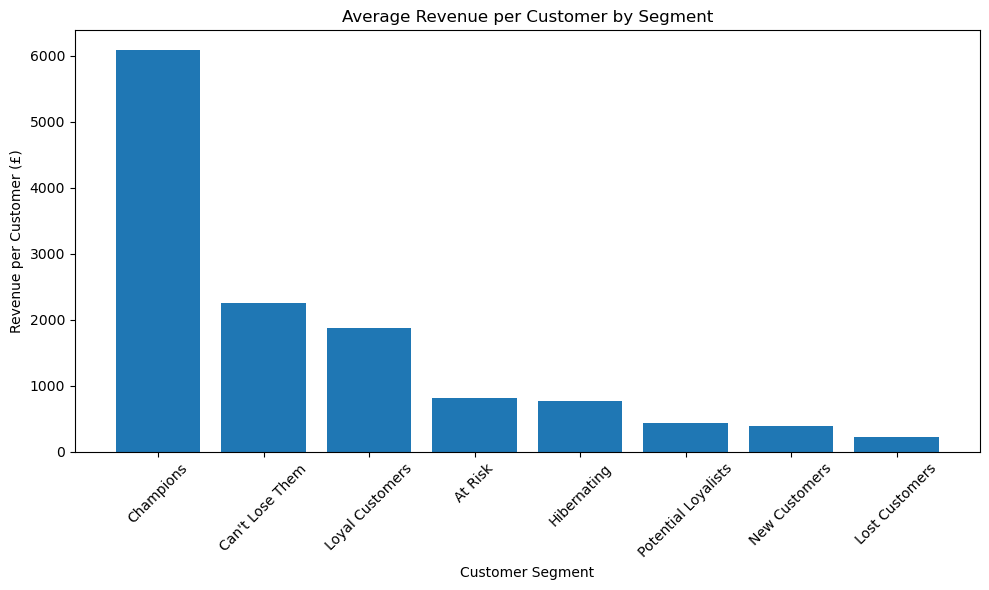

In [14]:
# Revenue per customer by segment

plt.figure(figsize=(10, 6))

plt.bar(
    segment_analysis["Segment"],
    segment_analysis["RevenuePerCustomer"]
)

plt.title("Average Revenue per Customer by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue per Customer (£)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [15]:
# Calculate customer-level metrics for CLV

customer_clv = df_clean.groupby("CustomerID").agg(
    TotalRevenue=("TotalAmount", "sum"),
    TotalOrders=("InvoiceNo", "nunique")
).reset_index()

# Calculate Average Order Value
customer_clv["AverageOrderValue"] = (
    customer_clv["TotalRevenue"]
    / customer_clv["TotalOrders"]
)

# Calculate CLV
customer_clv["CLV"] = (
    customer_clv["AverageOrderValue"]
    * customer_clv["TotalOrders"]
)

display(customer_clv.head())

,CustomerID,TotalRevenue,TotalOrders,AverageOrderValue,CLV
0,12346,77183.60,1,77183.600000,77183.60
1,12347,4310.00,7,615.714286,4310.00
2,12348,1797.24,4,449.310000,1797.24
3,12349,1757.55,1,1757.550000,1757.55
4,12350,334.40,1,334.400000,334.40


In [16]:
# Merge customer segments with CLV data

customer_clv_segment = customer_clv.merge(
    rfm[["CustomerID", "Segment"]],
    on="CustomerID",
    how="left"
)

# Display first 5 rows
display(customer_clv_segment.head())

,CustomerID,TotalRevenue,TotalOrders,AverageOrderValue,CLV,Segment
0,12346,77183.60,1,77183.600000,77183.60,Hibernating
1,12347,4310.00,7,615.714286,4310.00,Champions
2,12348,1797.24,4,449.310000,1797.24,Can't Lose Them
3,12349,1757.55,1,1757.550000,1757.55,Hibernating
4,12350,334.40,1,334.400000,334.40,Lost Customers


In [17]:
# Calculate average CLV by customer segment

clv_by_segment = (
    customer_clv_segment
    .groupby("Segment")["CLV"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

clv_by_segment.columns = [
    "Segment",
    "AverageCLV"
]

# Round values
clv_by_segment["AverageCLV"] = (
    clv_by_segment["AverageCLV"].round(2)
)

display(clv_by_segment)

,Segment,AverageCLV
0,Champions,6077.63
1,Can't Lose Them,2254.97
2,Loyal Customers,1874.81
3,At Risk,808.36
4,Hibernating,763.12
5,Potential Loyalists,436.25
6,New Customers,388.21
7,Lost Customers,230.23


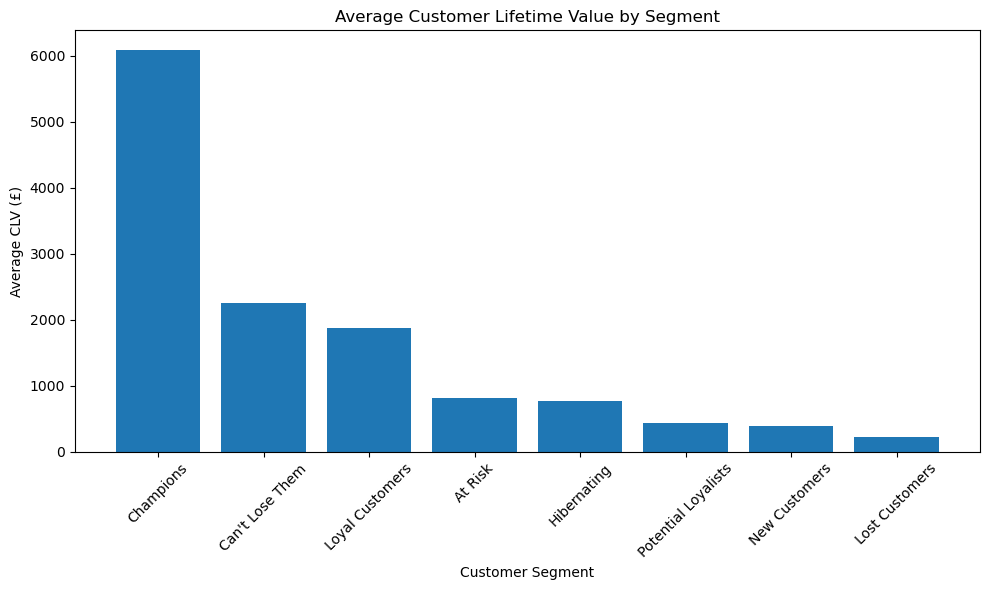

In [18]:
# Visualize average CLV by customer segment

plt.figure(figsize=(10, 6))

plt.bar(
    clv_by_segment["Segment"],
    clv_by_segment["AverageCLV"]
)

plt.title("Average Customer Lifetime Value by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average CLV (£)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# Key Findings

- The customer segmentation analysis identified eight distinct customer groups based on Recency, Frequency, and Monetary (RFM) behavior.

- Champions are the most valuable customer segment, with the highest total revenue contribution and an average CLV of £6,077.63 per customer.

- The Can't Lose Them segment has the second-highest average CLV of £2,254.97. These customers are highly valuable and should be prioritized for retention.

- Loyal Customers generated strong revenue and have an average CLV of £1,874.81, making them an important segment for maintaining long-term business growth.

- At Risk and Hibernating customers still contribute significant revenue, indicating an opportunity for targeted re-engagement campaigns.

- Lost Customers represent a relatively large customer group but have the lowest average CLV of £230.23, suggesting that recovery efforts should be selective and cost-effective.

- Potential Loyalists and New Customers have lower current customer value but may provide future growth opportunities through personalized engagement and promotions.

- The analysis demonstrates that customer value is not evenly distributed, with high-value segments contributing significantly more revenue per customer.

# Business Recommendations

## 1. Retain Champions

Champions are the highest-value customer segment, with the highest revenue contribution and an average CLV of £6,077.63. The business should focus on retaining these customers through loyalty programs, exclusive offers, early access to products, and personalized rewards.

## 2. Prioritize the "Can't Lose Them" Segment

The "Can't Lose Them" customers have a high average CLV of £2,254.97. Since these customers were previously valuable but may be becoming inactive, targeted retention campaigns, personalized discounts, and special offers should be used to encourage them to return.

## 3. Strengthen Relationships with Loyal Customers

Loyal Customers have an average CLV of £1,874.81 and contribute significant revenue. The business should maintain engagement through loyalty rewards, personalized recommendations, and regular communication.

## 4. Re-engage At Risk and Hibernating Customers

At Risk and Hibernating customers still represent significant revenue opportunities. Targeted email campaigns, limited-time discounts, and personalized product recommendations can help reactivate these customers.

## 5. Develop Potential Loyalists

Potential Loyalists can become high-value customers in the future. The business should encourage repeat purchases through promotional offers, product recommendations, and loyalty incentives.

## 6. Build Relationships with New Customers

New Customers should receive a positive onboarding experience and follow-up communication. Welcome offers and personalized recommendations may encourage them to make additional purchases.

## 7. Use Selective Recovery Strategies for Lost Customers

Lost Customers have the lowest average CLV of £230.23. Therefore, expensive retention campaigns may not be cost-effective. Low-cost automated campaigns can be used to attempt re-engagement.

## 8. Use Customer Segmentation for Personalized Marketing

Instead of applying the same marketing strategy to every customer, the business should use customer segments to deliver personalized offers and communication based on customer value and purchasing behavior.

# Conclusion

This project analyzed customer purchasing behavior using RFM analysis, customer segmentation, revenue analysis, and Customer Lifetime Value (CLV).

The analysis identified eight customer segments with different purchasing behaviors and levels of business value.

Champions were identified as the most valuable customer segment, generating the highest total revenue and an average CLV of £6,077.63 per customer.

The "Can't Lose Them" and "Loyal Customers" segments also demonstrated high customer value, making customer retention and engagement important business priorities.

At Risk and Hibernating customers represent potential revenue recovery opportunities through targeted re-engagement campaigns. Potential Loyalists and New Customers can be developed into higher-value segments through personalized offers and loyalty strategies.

Lost Customers had the lowest average CLV, indicating that recovery strategies for this group should remain cost-effective.

Overall, the project demonstrates how RFM analysis and customer segmentation can help businesses understand customer behavior, identify high-value customers, and develop more effective and personalized marketing strategies.

The insights generated from this analysis can support data-driven decision-making and improve customer retention, revenue growth, and long-term customer value.

In [19]:
print("Available important variables:")

for var in ["df", "df_clean", "rfm", "customer_clv", "customer_clv_segment"]:
    print(var, "→", var in globals())

Available important variables:
df → True
df_clean → True
rfm → True
customer_clv → True
customer_clv_segment → True


In [20]:
# Create final dataset for Power BI

powerbi_data = customer_clv_segment.copy()

# Save as CSV
powerbi_data.to_csv(
    "Customer_Segmentation_PowerBI.csv",
    index=False
)

print("Power BI dataset exported successfully!")
print("Shape:", powerbi_data.shape)

display(powerbi_data.head())

Power BI dataset exported successfully!
Shape: (4338, 6)


,CustomerID,TotalRevenue,TotalOrders,AverageOrderValue,CLV,Segment
0,12346,77183.60,1,77183.600000,77183.60,Hibernating
1,12347,4310.00,7,615.714286,4310.00,Champions
2,12348,1797.24,4,449.310000,1797.24,Can't Lose Them
3,12349,1757.55,1,1757.550000,1757.55,Hibernating
4,12350,334.40,1,334.400000,334.40,Lost Customers
